# Project Workflow Map: Notebooks 00–04

Visual overview of the pipeline from Cochrane PDF extraction through LLM evaluation.

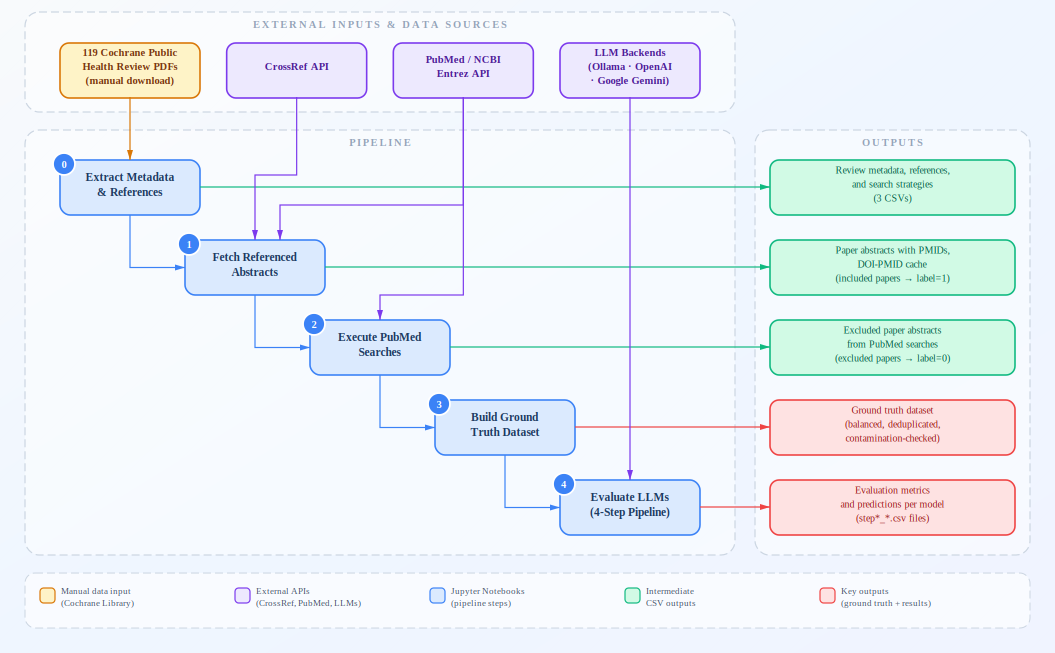

Exported to: c:\Users\juanx\Documents\LSE-UKHSA Project\Visualisations\workflow_map.html
Toggle between views with buttons or press 1/2 keys


In [1]:
from IPython.display import SVG, display, HTML
from html import escape as esc

# ═══════════════════════════════════════════════════════════════
#  PROJECT WORKFLOW MAP  —  v10 (with toggle views)
# ═══════════════════════════════════════════════════════════════

MARGIN = 25
SEC_LEFT = MARGIN

# ── Palette ──
INPUT_BG  = '#FEF3C7'; INPUT_BD = '#D97706'; INPUT_TX = '#78350F'
API_BG    = '#EDE9FE'; API_BD   = '#7C3AED'; API_TX   = '#4C1D95'
NB_BG     = '#DBEAFE'; NB_BD    = '#3B82F6'; NB_TX    = '#1E3A5F'
CSV_BG    = '#D1FAE5'; CSV_BD   = '#10B981'; CSV_TX   = '#065F46'
KEY_BG    = '#FEE2E2'; KEY_BD   = '#EF4444'; KEY_TX   = '#991B1B'
PIPE_COL  = '#3B82F6'
SECTION_BD = '#CBD5E1'

# ── Font ──
FONT = "'Times New Roman', Times, serif"

# ── Uniform box sizes ──
BOX_W, BOX_H = 140, 55
out_w, out_h = 245, 55

# ── Arrow stroke width ──
ARROW_SW = 1.2

# ── Section layout ──
SECTION_GAP = 18
input_sec_y = 12
input_sec_h = 100
input_sec_bottom = input_sec_y + input_sec_h
pipe_top = input_sec_bottom + SECTION_GAP

# ── Cascading notebook positions ──
H_STEP, V_STEP = 125, 80
nb_pos_raw = [(i * H_STEP, pipe_top + 30 + i * V_STEP) for i in range(5)]
content_width = nb_pos_raw[4][0] + BOX_W

# ── Pipeline section width ──
PIPE_PAD = 35
pipe_sec_w = content_width + 2 * PIPE_PAD
pipe_sec_x = SEC_LEFT
pipe_sec_right = pipe_sec_x + pipe_sec_w

# ── Center content within sections ──
content_offset = SEC_LEFT + PIPE_PAD
nb_pos = [(content_offset + x, y) for (x, y) in nb_pos_raw]

# ── Key alignment edges ──
NB0_LEFT  = nb_pos[0][0]
NB4_RIGHT = nb_pos[4][0] + BOX_W

# ── Output section ──
out_gap   = 20
out_pad   = 15
out_sec_w = out_w + 2 * out_pad
out_sec_x = pipe_sec_right + out_gap
out_x     = out_sec_x + out_pad
out_sec_right = out_sec_x + out_sec_w

# ── Pipeline vertical bounds ──
pipe_bottom = nb_pos[4][1] + BOX_H + 20
pipe_sec_h  = pipe_bottom - pipe_top

# ── Legend position ──
legend_h = 55
legend_y = pipe_bottom + SECTION_GAP

# ── Canvas size ──
W = out_sec_right + MARGIN
H = legend_y + legend_h + MARGIN

# ── Input boxes ──
inp_span = NB4_RIGHT - NB0_LEFT
inp_gap  = (inp_span - 4 * BOX_W) / 3

inp_specs = [
    (NB0_LEFT,                              ['119 Cochrane Public', 'Health Review PDFs', '(manual download)'],
     INPUT_BG, INPUT_BD, INPUT_TX),
    (NB0_LEFT + 1 * (BOX_W + inp_gap),      ['CrossRef API'],
     API_BG,   API_BD,   API_TX),
    (NB0_LEFT + 2 * (BOX_W + inp_gap),      ['PubMed / NCBI', 'Entrez API'],
     API_BG,   API_BD,   API_TX),
    (NB0_LEFT + 3 * (BOX_W + inp_gap),      ['LLM Backends', '(Ollama · OpenAI', '· Google Gemini)'],
     API_BG,   API_BD,   API_TX),
]

# ══════════════════════════════════════════════════════════════════
# TWO VIEW MODES: Description vs Filename
# ══════════════════════════════════════════════════════════════════

# Description view labels (notebooks)
nb_labels_desc = [
    ['Extract Metadata', '& References'],
    ['Fetch Referenced', 'Abstracts'],
    ['Execute PubMed', 'Searches'],
    ['Build Ground', 'Truth Dataset'],
    ['Evaluate LLMs', '(4-Step Pipeline)'],
]

# Filename view labels (notebooks)
nb_labels_file = [
    ['00_extract_metadata_', 'and_references'],
    ['01_fetch_referenced_', 'abstracts'],
    ['02_execute_pubmed_', 'searches'],
    ['03_build_ground_', 'truth'],
    ['04_evaluate_', 'llms'],
]

# Description view outputs
out_labels_desc = [
    (['Review metadata, references,', 'and search strategies', '(3 CSVs)'],
     CSV_BG, CSV_BD, CSV_TX),
    (['Paper abstracts with PMIDs,', 'DOI-PMID cache', '(included papers → label=1)'],
     CSV_BG, CSV_BD, CSV_TX),
    (['Excluded paper abstracts', 'from PubMed searches', '(excluded papers → label=0)'],
     CSV_BG, CSV_BD, CSV_TX),
    (['Ground truth dataset', '(balanced, deduplicated,', 'contamination-checked)'],
     KEY_BG, KEY_BD, KEY_TX),
    (['Evaluation metrics', 'and predictions per model', '(step*_*.csv files)'],
     KEY_BG, KEY_BD, KEY_TX),
]

# Filename view outputs
out_labels_file = [
    (['review_metadata.csv', 'categorized_references.csv', 'search_strategies.csv'],
     CSV_BG, CSV_BD, CSV_TX),
    (['referenced_paper_abstracts.csv', 'doi_pmid_cache.csv', 'crossref_matching_progress.csv'],
     CSV_BG, CSV_BD, CSV_TX),
    (['pubmed_excluded_abstracts.csv', 'pubmed_search_results.csv', 'pubmed_search_progress.csv'],
     CSV_BG, CSV_BD, CSV_TX),
    (['ground_truth_validation_', 'dataset.csv', ''],
     KEY_BG, KEY_BD, KEY_TX),
    (['Data/results/', 'step{N}_{model}_{variant}.csv', ''],
     KEY_BG, KEY_BD, KEY_TX),
]

# ══════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════

def rect(x, y, w, h, fill, stroke, rx=10, filt=None):
    f = f' filter="url(#{filt})"' if filt else ''
    return (f'<rect x="{x}" y="{y}" width="{w}" height="{h}" rx="{rx}" '
            f'fill="{fill}" stroke="{stroke}" stroke-width="1.6"{f}/>')

def text_block(cx, cy, lines, fill, fs=12, fw='normal', ls=17):
    sy = cy - (len(lines) - 1) * ls / 2
    return ''.join(
        f'<text x="{cx}" y="{sy + i*ls}" text-anchor="middle" '
        f'font-family="{FONT}" '
        f'font-size="{fs}" font-weight="{fw}" fill="{fill}">{esc(l)}</text>'
        for i, l in enumerate(lines))

def marker(mid, color):
    w, h = 10, 7; hw = h / 2
    return (f'<marker id="{mid}" markerWidth="{w}" markerHeight="{h}" '
            f'refX="{w}" refY="{hw}" orient="auto" markerUnits="userSpaceOnUse">'
            f'<path d="M 0,0.5 L {w},{hw} L 0,{h - 0.5} Z" '
            f'fill="{color}" stroke="none"/></marker>')

def line_a(x1, y1, x2, y2, color, sw=2, mid=''):
    m = f' marker-end="url(#{mid})"' if mid else ''
    return (f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" '
            f'stroke="{color}" stroke-width="{sw}"{m}/>')

def path_a(d_str, color, sw=2, mid=''):
    m  = f' marker-end="url(#{mid})"' if mid else ''
    return (f'<path d="{d_str}" fill="none" stroke="{color}" '
            f'stroke-width="{sw}"{m}/>')

def section_box(x, y, w, h, label):
    s = (f'<rect x="{x}" y="{y}" width="{w}" height="{h}" rx="14" '
         f'fill="white" fill-opacity="0.45" stroke="{SECTION_BD}" '
         f'stroke-width="1.2" stroke-dasharray="8 4"/>')
    s += (f'<text x="{x + w/2}" y="{y + 16}" text-anchor="middle" '
          f'font-family="{FONT}" '
          f'font-size="10.5" font-weight="600" fill="#94A3B8" '
          f'letter-spacing="1.8">{esc(label)}</text>')
    return s

# ══════════════════════════════════════════════════════════
# BUILD SVG FUNCTION
# ══════════════════════════════════════════════════════════

def build_svg(nb_labels, out_labels, view_id='desc'):
    parts = []
    
    # Unique ID suffix for this view to avoid conflicts
    s = f"_{view_id}"
    
    # ── SVG open + defs ──
    parts.append(f'<svg xmlns="http://www.w3.org/2000/svg" width="{W}" height="{H}" '
                 f'viewBox="0 0 {W} {H}" class="workflow-svg" data-view="{view_id}">')
    parts.append('<defs>')
    parts.append(f'<filter id="sh{s}" x="-5%" y="-5%" width="112%" height="118%">'
                 '<feDropShadow dx="1.5" dy="2.5" stdDeviation="4" flood-opacity="0.11"/></filter>')
    parts.append(f'<filter id="shL{s}" x="-4%" y="-4%" width="110%" height="114%">'
                 '<feDropShadow dx="1" dy="1.5" stdDeviation="2.5" flood-opacity="0.07"/></filter>')
    parts.append(marker(f'aP{s}', PIPE_COL))
    parts.append(marker(f'aI{s}', INPUT_BD))
    parts.append(marker(f'aA{s}', API_BD))
    parts.append(marker(f'aC{s}', CSV_BD))
    parts.append(marker(f'aK{s}', KEY_BD))
    parts.append(f'<linearGradient id="bg{s}" x1="0" y1="0" x2="1" y2="1">'
                 '<stop offset="0%" stop-color="#F8FAFC"/>'
                 '<stop offset="50%" stop-color="#EFF6FF"/>'
                 '<stop offset="100%" stop-color="#F0F4FF"/></linearGradient>')
    parts.append(f'<pattern id="grid{s}" width="40" height="40" patternUnits="userSpaceOnUse">'
                 '<path d="M 40 0 L 0 40" stroke="#E2E8F0" stroke-width="0.4" opacity="0.35"/>'
                 '</pattern>')
    parts.append('</defs>')

    # ── Background ──
    parts.append(f'<rect width="{W}" height="{H}" fill="url(#bg{s})"/>')
    parts.append(f'<rect width="{W}" height="{H}" fill="url(#grid{s})" opacity="0.25"/>')

    # ── Section containers ──
    parts.append(section_box(SEC_LEFT, input_sec_y, pipe_sec_w, input_sec_h, 'EXTERNAL INPUTS & DATA SOURCES'))
    parts.append(section_box(pipe_sec_x, pipe_top, pipe_sec_w, pipe_sec_h, 'PIPELINE'))
    parts.append(section_box(out_sec_x, pipe_top, out_sec_w, pipe_sec_h, 'OUTPUTS'))

    # ── Input boxes ──
    inp_cy = input_sec_y + input_sec_h / 2 + 8
    for (ix, lines, bg, bd, tx) in inp_specs:
        parts.append(rect(ix, inp_cy - BOX_H // 2, BOX_W, BOX_H, bg, bd, rx=9, filt=f'shL{s}'))
        parts.append(text_block(ix + BOX_W / 2, inp_cy, lines, tx, fs=10.5, fw='600', ls=14))

    # ── Notebook boxes ──
    for i, (nx, ny) in enumerate(nb_pos):
        parts.append(rect(nx, ny, BOX_W, BOX_H, NB_BG, NB_BD, filt=f'sh{s}'))
        bx, by = nx - 7, ny - 7
        parts.append(f'<circle cx="{bx + 11}" cy="{by + 11}" r="11" '
                     f'fill="{NB_BD}" stroke="white" stroke-width="1.8"/>')
        parts.append(f'<text x="{bx + 11}" y="{by + 15}" text-anchor="middle" '
                     f'font-family="{FONT}" font-size="10.5" '
                     f'font-weight="700" fill="white">{i}</text>')
        nb_fs = 10 if view_id == 'file' else 11.5
        nb_ls = 13 if view_id == 'file' else 15
        parts.append(text_block(nx + BOX_W / 2, ny + BOX_H / 2 + 1,
                                nb_labels[i], NB_TX, fs=nb_fs, fw='600', ls=nb_ls))

    # ── Output boxes ──
    for i, (nx, ny) in enumerate(nb_pos):
        ol, obg, obd, otx = out_labels[i]
        ol_filtered = [l for l in ol if l]
        oy = ny + (BOX_H - out_h) // 2
        parts.append(rect(out_x, oy, out_w, out_h, obg, obd, rx=9, filt=f'shL{s}'))
        out_fs = 9.5 if view_id == 'file' else 10
        parts.append(text_block(out_x + out_w / 2, oy + out_h / 2,
                                ol_filtered, otx, fs=out_fs, fw='500', ls=14))

    # ── Arrows: Notebook → Notebook ──
    for i in range(4):
        sx = nb_pos[i][0] + BOX_W / 2
        sy = nb_pos[i][1] + BOX_H
        ex = nb_pos[i + 1][0]
        ey = nb_pos[i + 1][1] + BOX_H / 2
        parts.append(path_a(f'M {sx},{sy} L {sx},{ey} L {ex},{ey}',
                            PIPE_COL, sw=ARROW_SW, mid=f'aP{s}'))

    # ── Arrows: Notebook → Output ──
    for i, (nx, ny) in enumerate(nb_pos):
        mid = f'aC{s}' if i < 3 else f'aK{s}'
        col = CSV_BD if i < 3 else KEY_BD
        cy = ny + BOX_H // 2
        parts.append(line_a(nx + BOX_W, cy, out_x, cy, col, sw=ARROW_SW, mid=mid))

    # ── Arrows: Inputs → Notebooks ──
    ic = [inp_specs[j][0] + BOX_W / 2 for j in range(4)]
    inp_bot = inp_cy + BOX_H // 2

    # Input 0 → NB0
    px0, py0 = nb_pos[0]
    tx0 = px0 + BOX_W / 2
    mid_y0 = inp_bot + 15
    parts.append(path_a(f'M {ic[0]},{inp_bot} L {ic[0]},{mid_y0} L {tx0},{mid_y0} L {tx0},{py0}',
                        INPUT_BD, sw=ARROW_SW, mid=f'aI{s}'))

    # Input 1 → NB1
    px1, py1 = nb_pos[1]
    tx1 = px1 + BOX_W / 2
    mid_y1 = py1 - 65
    parts.append(path_a(f'M {ic[1]},{inp_bot} L {ic[1]},{mid_y1} L {tx1},{mid_y1} L {tx1},{py1}',
                        API_BD, sw=ARROW_SW, mid=f'aA{s}'))

    # Input 2 → NB1 (offset)
    tx1b = px1 + BOX_W / 2 + 25
    mid_y1b = py1 - 35
    parts.append(path_a(f'M {ic[2]},{inp_bot} L {ic[2]},{mid_y1b} L {tx1b},{mid_y1b} L {tx1b},{py1}',
                        API_BD, sw=ARROW_SW, mid=f'aA{s}'))

    # Input 2 → NB2
    px2, py2 = nb_pos[2]
    tx2 = px2 + BOX_W / 2
    mid_y2 = py2 - 25
    parts.append(path_a(f'M {ic[2]},{inp_bot} L {ic[2]},{mid_y2} L {tx2},{mid_y2} L {tx2},{py2}',
                        API_BD, sw=ARROW_SW, mid=f'aA{s}'))

    # Input 3 → NB4
    px4, py4 = nb_pos[4]
    tx4 = px4 + BOX_W / 2
    mid_y4 = py4 - 25
    parts.append(path_a(f'M {ic[3]},{inp_bot} L {ic[3]},{mid_y4} L {tx4},{mid_y4} L {tx4},{py4}',
                        API_BD, sw=ARROW_SW, mid=f'aA{s}'))

    # ── Legend ──
    legend_w = out_sec_right - SEC_LEFT
    parts.append(f'<rect x="{SEC_LEFT}" y="{legend_y}" width="{legend_w}" height="{legend_h}" '
                 f'rx="10" fill="white" fill-opacity="0.6" stroke="{SECTION_BD}" '
                 f'stroke-width="1" stroke-dasharray="8 4"/>')

    legend = [
        (INPUT_BG, INPUT_BD, ['Manual data input', '(Cochrane Library)']),
        (API_BG,   API_BD,   ['External APIs', '(CrossRef, PubMed, LLMs)']),
        (NB_BG,    NB_BD,    ['Jupyter Notebooks', '(pipeline steps)']),
        (CSV_BG,   CSV_BD,   ['Intermediate', 'CSV outputs']),
        (KEY_BG,   KEY_BD,   ['Key outputs', '(ground truth + results)']),
    ]
    sp = (legend_w - 30) // len(legend)
    ly = legend_y + 15
    for j, (bg, bd, lines) in enumerate(legend):
        lx = SEC_LEFT + 15 + j * sp
        parts.append(f'<rect x="{lx}" y="{ly}" width="15" height="15" rx="3.5" '
                     f'fill="{bg}" stroke="{bd}" stroke-width="1.2"/>')
        parts.append(f'<text x="{lx + 21}" y="{ly + 6}" '
                     f'font-family="{FONT}" '
                     f'font-size="9" fill="#475569">{esc(lines[0])}</text>')
        parts.append(f'<text x="{lx + 21}" y="{ly + 18}" '
                     f'font-family="{FONT}" '
                     f'font-size="9" fill="#475569">{esc(lines[1])}</text>')

    parts.append('</svg>')
    return '\n'.join(parts)

# ══════════════════════════════════════════════════════════
# BUILD BOTH SVG VIEWS
# ══════════════════════════════════════════════════════════

svg_desc = build_svg(nb_labels_desc, out_labels_desc, 'desc')
svg_file = build_svg(nb_labels_file, out_labels_file, 'file')

# Display description view in notebook
display(SVG(data=svg_desc))

# ══════════════════════════════════════════════════════════
# EXPORT HTML WITH TOGGLE
# ══════════════════════════════════════════════════════════

html_template = f'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Project Workflow Map</title>
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        body {{
            font-family: 'Times New Roman', Times, serif;
            background: linear-gradient(135deg, #F8FAFC 0%, #EFF6FF 50%, #F0F4FF 100%);
            min-height: 100vh;
            overflow: hidden;
        }}
        
        .toggle-container {{
            position: fixed;
            top: 15px;
            left: 50%;
            transform: translateX(-50%);
            z-index: 1000;
            display: flex;
            gap: 0;
            background: white;
            border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.15);
            overflow: hidden;
        }}
        
        .toggle-btn {{
            padding: 10px 20px;
            border: none;
            background: white;
            cursor: pointer;
            font-family: 'Times New Roman', Times, serif;
            font-size: 13px;
            font-weight: 500;
            color: #64748B;
            transition: all 0.2s;
        }}
        
        .toggle-btn:hover {{
            background: #F1F5F9;
        }}
        
        .toggle-btn.active {{
            background: #3B82F6;
            color: white;
        }}
        
        .svg-container {{
            width: 100vw;
            height: 100vh;
            overflow: hidden;
            cursor: grab;
            padding-top: 60px;
        }}
        
        .svg-container:active {{ cursor: grabbing; }}
        
        .svg-wrapper {{
            transform-origin: 0 0;
            transition: transform 0.1s ease-out;
        }}
        
        .view-desc, .view-file {{ display: none; }}
        .view-desc.active, .view-file.active {{ display: block; }}
        
        .help-text {{
            position: fixed;
            bottom: 15px;
            left: 50%;
            transform: translateX(-50%);
            background: rgba(255,255,255,0.9);
            padding: 8px 16px;
            border-radius: 6px;
            font-size: 11px;
            color: #64748B;
            box-shadow: 0 1px 4px rgba(0,0,0,0.1);
        }}
    </style>
</head>
<body>
    <div class="toggle-container">
        <button class="toggle-btn active" data-view="desc">Description View</button>
        <button class="toggle-btn" data-view="file">Filename View</button>
    </div>
    
    <div class="svg-container" id="container">
        <div class="svg-wrapper" id="wrapper">
            <div class="view-desc active">{svg_desc}</div>
            <div class="view-file">{svg_file}</div>
        </div>
    </div>
    
    <div class="help-text">Scroll to zoom | Drag to pan | Double-click to zoom in | Press 0 to reset | Press 1/2 to toggle views</div>

    <script>
        const container = document.getElementById('container');
        const wrapper = document.getElementById('wrapper');
        const toggleBtns = document.querySelectorAll('.toggle-btn');
        
        let scale = 1;
        let translateX = 50;
        let translateY = 20;
        let isDragging = false;
        let startX, startY;
        
        const MIN_SCALE = 0.3;
        const MAX_SCALE = 4;
        const ZOOM_STEP = 0.15;
        
        // Toggle view
        toggleBtns.forEach(btn => {{
            btn.addEventListener('click', () => {{
                toggleBtns.forEach(b => b.classList.remove('active'));
                btn.classList.add('active');
                const view = btn.dataset.view;
                document.querySelectorAll('.view-desc, .view-file').forEach(el => el.classList.remove('active'));
                document.querySelector('.view-' + view).classList.add('active');
            }});
        }});
        
        function updateTransform(smooth = true) {{
            wrapper.style.transition = smooth ? 'transform 0.3s ease-out' : 'transform 0.05s ease-out';
            wrapper.style.transform = `translate(${{translateX}}px, ${{translateY}}px) scale(${{scale}})`;
        }}
        
        container.addEventListener('wheel', (e) => {{
            e.preventDefault();
            const delta = e.deltaY > 0 ? -ZOOM_STEP : ZOOM_STEP;
            const newScale = Math.max(MIN_SCALE, Math.min(MAX_SCALE, scale + delta));
            
            const rect = container.getBoundingClientRect();
            const mouseX = e.clientX - rect.left;
            const mouseY = e.clientY - rect.top;
            
            const scaleChange = newScale / scale;
            translateX = mouseX - (mouseX - translateX) * scaleChange;
            translateY = mouseY - (mouseY - translateY) * scaleChange;
            
            scale = newScale;
            updateTransform(false);
        }}, {{ passive: false }});
        
        container.addEventListener('mousedown', (e) => {{
            isDragging = true;
            startX = e.clientX - translateX;
            startY = e.clientY - translateY;
            container.style.cursor = 'grabbing';
        }});
        
        document.addEventListener('mousemove', (e) => {{
            if (!isDragging) return;
            translateX = e.clientX - startX;
            translateY = e.clientY - startY;
            updateTransform(false);
        }});
        
        document.addEventListener('mouseup', () => {{
            isDragging = false;
            container.style.cursor = 'grab';
        }});
        
        container.addEventListener('dblclick', (e) => {{
            const rect = container.getBoundingClientRect();
            const mouseX = e.clientX - rect.left;
            const mouseY = e.clientY - rect.top;
            
            const newScale = Math.min(MAX_SCALE, scale + 0.5);
            const scaleChange = newScale / scale;
            translateX = mouseX - (mouseX - translateX) * scaleChange;
            translateY = mouseY - (mouseY - translateY) * scaleChange;
            
            scale = newScale;
            updateTransform();
        }});
        
        document.addEventListener('keydown', (e) => {{
            if (e.key === '+' || e.key === '=') {{
                scale = Math.min(MAX_SCALE, scale + ZOOM_STEP);
                updateTransform();
            }}
            if (e.key === '-') {{
                scale = Math.max(MIN_SCALE, scale - ZOOM_STEP);
                updateTransform();
            }}
            if (e.key === '0' || e.key === 'Escape') {{
                scale = 1;
                translateX = 50;
                translateY = 20;
                updateTransform();
            }}
            // Toggle views with 1 and 2 keys
            if (e.key === '1') {{
                toggleBtns[0].click();
            }}
            if (e.key === '2') {{
                toggleBtns[1].click();
            }}
        }});
        
        updateTransform();
    </script>
</body>
</html>'''

# Write to file
output_path = r'c:\Users\juanx\Documents\LSE-UKHSA Project\Visualisations\workflow_map.html'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(html_template)

print(f"Exported to: {output_path}")
print("Toggle between views with buttons or press 1/2 keys")

# Search Strategy Translation Visualisation

Interactive visualisation showing the translation of Ovid MEDLINE search strategies to PubMed syntax across all Cochrane reviews.

In [2]:
import pandas as pd
from pathlib import Path
from IPython.display import HTML, display
import json
import re
from html import escape

# ═══════════════════════════════════════════════════════════════
#  SEARCH STRATEGY TRANSLATION VISUALISATION
# ═══════════════════════════════════════════════════════════════

# Setup paths
notebook_dir = Path.cwd()
project_root = notebook_dir if (notebook_dir / "Data").exists() else notebook_dir.parent
DATA_DIR = project_root / "Data"
VIS_DIR = project_root / "Visualisations"

# Load search strategies
df = pd.read_csv(DATA_DIR / "search_strategies.csv")

# Filter for rows with actual translations
translated = df[
    (df['pubmed_query'].notna()) & 
    (df['pubmed_query'] != '') & 
    (df['database'] != 'narrative_only')
].copy()

# Load review metadata for titles
meta_df = pd.read_csv(DATA_DIR / "review_metadata.csv")
meta_dict = dict(zip(meta_df['doi'], meta_df['title']))

# Prepare data for visualization
translations_data = []
for _, row in translated.iterrows():
    doi = row['doi']
    title = meta_dict.get(doi, "Unknown Title")
    # Clean title
    if isinstance(title, str):
        title = title.split('(Review)')[0].strip()
        title = title[:80] + '...' if len(title) > 80 else title
    
    # Parse translation notes into categories
    notes = str(row['translation_notes']) if pd.notna(row['translation_notes']) else ''
    
    translations_data.append({
        'doi': doi,
        'title': title,
        'database': str(row['database']),
        'raw_strategy': str(row['raw_strategy']) if pd.notna(row['raw_strategy']) else '',
        'pubmed_query': str(row['pubmed_query']) if pd.notna(row['pubmed_query']) else '',
        'notes': notes,
        'is_success': notes == 'success' or 'success' in notes,
        'has_adjacency': 'adjacency' in notes,
        'has_wildcard': 'wildcard' in notes,
        'has_mp': 'mp_approximated' in notes,
        'has_near': 'near' in notes,
    })

# Calculate statistics
total_reviews = len(df['doi'].unique())
total_translated = len(translated)
success_count = sum(1 for t in translations_data if t['is_success'])
with_modifications = total_translated - success_count

# Count modification types
adj_count = sum(1 for t in translations_data if t['has_adjacency'])
wild_count = sum(1 for t in translations_data if t['has_wildcard'])
mp_count = sum(1 for t in translations_data if t['has_mp'])
near_count = sum(1 for t in translations_data if t['has_near'])

# Convert to JSON for JavaScript
translations_json = json.dumps(translations_data)

print(f"✓ Loaded {total_translated} translations from {total_reviews} total reviews")
print(f"  - Direct translations: {success_count}")
print(f"  - With syntax adaptations: {with_modifications}")

# ═══════════════════════════════════════════════════════════════
# BUILD HTML VISUALISATION
# ═══════════════════════════════════════════════════════════════

html_content = f'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Search Strategy Translation — Ovid to PubMed</title>
    <link href="https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;500&display=swap" rel="stylesheet">
    <style>
        :root {{
            --bg-primary: #F8FAFC;
            --bg-secondary: #FFFFFF;
            --bg-card: #F1F5F9;
            --bg-code-ovid: #EFF6FF;
            --bg-code-pubmed: #ECFDF5;
            --accent-blue: #2563EB;
            --accent-green: #059669;
            --accent-purple: #7C3AED;
            --accent-amber: #D97706;
            --accent-rose: #E11D48;
            --text-primary: #1E293B;
            --text-secondary: #475569;
            --text-muted: #64748B;
            --border-color: #CBD5E1;
        }}
        
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        
        body {{
            font-family: 'Times New Roman', Times, serif;
            background: var(--bg-primary);
            color: var(--text-primary);
            min-height: 100vh;
            line-height: 1.6;
        }}
        
        .container {{
            max-width: 1400px;
            margin: 0 auto;
            padding: 40px 24px;
        }}
        
        /* Header */
        .header {{
            text-align: center;
            margin-bottom: 48px;
        }}
        
        .header h1 {{
            font-size: 2.5rem;
            font-weight: 700;
            background: linear-gradient(135deg, var(--accent-blue), var(--accent-purple));
            -webkit-background-clip: text;
            -webkit-text-fill-color: transparent;
            background-clip: text;
            margin-bottom: 12px;
        }}
        
        .header p {{
            color: var(--text-secondary);
            font-size: 1.1rem;
            max-width: 600px;
            margin: 0 auto;
        }}
        
        /* Stats Dashboard */
        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 20px;
            margin-bottom: 40px;
        }}
        
        .stat-card {{
            background: var(--bg-secondary);
            border-radius: 16px;
            padding: 24px;
            border: 1px solid var(--border-color);
            text-align: center;
            transition: transform 0.2s, box-shadow 0.2s;
        }}
        
        .stat-card:hover {{
            transform: translateY(-4px);
            box-shadow: 0 12px 40px rgba(0,0,0,0.1);
        }}
        
        .stat-value {{
            font-size: 2.5rem;
            font-weight: 700;
            margin-bottom: 8px;
        }}
        
        .stat-value.blue {{ color: var(--accent-blue); }}
        .stat-value.green {{ color: var(--accent-green); }}
        .stat-value.purple {{ color: var(--accent-purple); }}
        .stat-value.amber {{ color: var(--accent-amber); }}
        
        .stat-label {{
            color: var(--text-secondary);
            font-size: 0.9rem;
            font-weight: 500;
        }}
        
        /* Legend */
        .legend {{
            display: flex;
            flex-wrap: wrap;
            gap: 24px;
            justify-content: center;
            margin-bottom: 32px;
            padding: 20px;
            background: var(--bg-secondary);
            border-radius: 12px;
            border: 1px solid var(--border-color);
        }}
        
        .legend-item {{
            display: flex;
            align-items: center;
            gap: 8px;
            font-size: 0.85rem;
            color: var(--text-secondary);
        }}
        
        .legend-color {{
            width: 12px;
            height: 12px;
            border-radius: 3px;
        }}
        
        /* Search and Filter */
        .controls {{
            display: flex;
            gap: 16px;
            margin-bottom: 24px;
            flex-wrap: wrap;
        }}
        
        .search-box {{
            flex: 1;
            min-width: 250px;
            position: relative;
        }}
        
        .search-box input {{
            width: 100%;
            padding: 14px 20px 14px 48px;
            background: var(--bg-secondary);
            border: 1px solid var(--border-color);
            border-radius: 12px;
            color: var(--text-primary);
            font-size: 1rem;
            font-family: inherit;
            transition: border-color 0.2s, box-shadow 0.2s;
        }}
        
        .search-box input:focus {{
            outline: none;
            border-color: var(--accent-blue);
            box-shadow: 0 0 0 3px rgba(59, 130, 246, 0.2);
        }}
        
        .search-box::before {{
            content: '🔍';
            position: absolute;
            left: 16px;
            top: 50%;
            transform: translateY(-50%);
            font-size: 1.1rem;
        }}
        
        .filter-btn {{
            padding: 14px 24px;
            background: var(--bg-secondary);
            border: 1px solid var(--border-color);
            border-radius: 12px;
            color: var(--text-primary);
            font-size: 0.9rem;
            font-family: inherit;
            cursor: pointer;
            transition: all 0.2s;
        }}
        
        .filter-btn:hover {{
            background: var(--bg-card);
        }}
        
        .filter-btn.active {{
            background: var(--accent-blue);
            border-color: var(--accent-blue);
        }}
        
        /* Translation Cards */
        .translations-list {{
            display: flex;
            flex-direction: column;
            gap: 16px;
        }}
        
        .translation-card {{
            background: var(--bg-secondary);
            border-radius: 16px;
            border: 1px solid var(--border-color);
            overflow: hidden;
            transition: transform 0.2s, box-shadow 0.2s;
        }}
        
        .translation-card:hover {{
            transform: translateX(4px);
            box-shadow: 0 8px 30px rgba(0,0,0,0.08);
        }}
        
        .card-header {{
            padding: 20px 24px;
            cursor: pointer;
            display: flex;
            justify-content: space-between;
            align-items: center;
            gap: 16px;
            border-bottom: 1px solid transparent;
            transition: background 0.2s;
        }}
        
        .card-header:hover {{
            background: rgba(0,0,0,0.02);
        }}
        
        .card-header.expanded {{
            border-bottom-color: var(--border-color);
        }}
        
        .card-info {{
            flex: 1;
            min-width: 0;
        }}
        
        .card-doi {{
            font-family: 'JetBrains Mono', monospace;
            font-size: 0.85rem;
            color: var(--accent-blue);
            font-weight: 500;
            margin-bottom: 4px;
        }}
        
        .card-title {{
            font-size: 1rem;
            font-weight: 500;
            color: var(--text-primary);
            white-space: nowrap;
            overflow: hidden;
            text-overflow: ellipsis;
        }}
        
        .card-badges {{
            display: flex;
            gap: 8px;
            flex-shrink: 0;
        }}
        
        .badge {{
            padding: 4px 12px;
            border-radius: 20px;
            font-size: 0.75rem;
            font-weight: 500;
        }}
        
        .badge-success {{
            background: rgba(16, 185, 129, 0.2);
            color: var(--accent-green);
        }}
        
        .badge-modified {{
            background: rgba(245, 158, 11, 0.2);
            color: var(--accent-amber);
        }}
        
        .expand-icon {{
            width: 24px;
            height: 24px;
            display: flex;
            align-items: center;
            justify-content: center;
            color: var(--text-muted);
            transition: transform 0.3s;
        }}
        
        .card-header.expanded .expand-icon {{
            transform: rotate(180deg);
        }}
        
        /* Expanded Content */
        .card-content {{
            display: none;
            padding: 0;
        }}
        
        .card-content.show {{
            display: block;
        }}
        
        .code-comparison {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 0;
        }}
        
        @media (max-width: 900px) {{
            .code-comparison {{
                grid-template-columns: 1fr;
            }}
        }}
        
        .code-panel {{
            padding: 20px;
        }}
        
        .code-panel.ovid {{
            background: var(--bg-code-ovid);
            border-right: 1px solid var(--border-color);
        }}
        
        .code-panel.pubmed {{
            background: var(--bg-code-pubmed);
        }}
        
        @media (max-width: 900px) {{
            .code-panel.ovid {{
                border-right: none;
                border-bottom: 1px solid var(--border-color);
            }}
        }}
        
        .code-label {{
            font-size: 0.75rem;
            font-weight: 600;
            text-transform: uppercase;
            letter-spacing: 1px;
            margin-bottom: 12px;
            display: flex;
            align-items: center;
            gap: 8px;
        }}
        
        .code-panel.ovid .code-label {{
            color: #1D4ED8;
        }}
        
        .code-panel.pubmed .code-label {{
            color: #047857;
        }}
        
        .code-block {{
            font-family: 'JetBrains Mono', monospace;
            font-size: 0.8rem;
            line-height: 1.7;
            white-space: pre-wrap;
            word-break: break-all;
            color: #1E293B;
            max-height: 300px;
            overflow-y: auto;
        }}
        
        .code-block::-webkit-scrollbar {{
            width: 6px;
        }}
        
        .code-block::-webkit-scrollbar-track {{
            background: transparent;
        }}
        
        .code-block::-webkit-scrollbar-thumb {{
            background: var(--border-color);
            border-radius: 3px;
        }}
        
        /* Syntax Highlighting */
        .code-block .mesh {{ color: #DB2777; font-weight: 500; }}
        .code-block .field {{ color: #B45309; }}
        .code-block .bool {{ color: #2563EB; font-weight: 600; }}
        .code-block .num {{ color: #7C3AED; }}
        .code-block .wild {{ color: #DC2626; }}
        
        /* Translation Notes */
        .translation-notes {{
            padding: 16px 20px;
            background: rgba(124, 58, 237, 0.05);
            border-top: 1px solid var(--border-color);
            display: flex;
            align-items: center;
            gap: 12px;
        }}
        
        .notes-icon {{
            font-size: 1.2rem;
        }}
        
        .notes-text {{
            font-size: 0.85rem;
            color: var(--text-secondary);
        }}
        
        .notes-text strong {{
            color: var(--accent-purple);
        }}
        
        /* Empty State */
        .empty-state {{
            text-align: center;
            padding: 60px 20px;
            color: var(--text-muted);
        }}
        
        .empty-state-icon {{
            font-size: 3rem;
            margin-bottom: 16px;
        }}
        
        /* Arrow Animation */
        .arrow-animation {{
            display: flex;
            align-items: center;
            justify-content: center;
            padding: 8px;
            color: var(--accent-purple);
            font-size: 1.5rem;
        }}
        
        /* Footer */
        .footer {{
            margin-top: 48px;
            text-align: center;
            color: var(--text-muted);
            font-size: 0.85rem;
        }}
        
        /* Animations */
        @keyframes fadeIn {{
            from {{ opacity: 0; transform: translateY(10px); }}
            to {{ opacity: 1; transform: translateY(0); }}
        }}
        
        .translation-card {{
            animation: fadeIn 0.3s ease-out;
        }}
    </style>
</head>
<body>
    <div class="container">
        <header class="header">
            <h1>Search Strategy Translation</h1>
            <p>Automated conversion of Ovid MEDLINE search strategies to PubMed syntax across {total_reviews} Cochrane Public Health Reviews</p>
        </header>
        
        <div class="stats-grid">
            <div class="stat-card">
                <div class="stat-value blue">{total_reviews}</div>
                <div class="stat-label">Total Reviews</div>
            </div>
            <div class="stat-card">
                <div class="stat-value green">{total_translated}</div>
                <div class="stat-label">Strategies Translated</div>
            </div>
            <div class="stat-card">
                <div class="stat-value purple">{success_count}</div>
                <div class="stat-label">Direct Translations</div>
            </div>
            <div class="stat-card">
                <div class="stat-value amber">{with_modifications}</div>
                <div class="stat-label">With Syntax Adaptations</div>
            </div>
        </div>
        
        <div class="legend">
            <div class="legend-item">
                <div class="legend-color" style="background: #DB2777;"></div>
                <span>MeSH Terms</span>
            </div>
            <div class="legend-item">
                <div class="legend-color" style="background: #B45309;"></div>
                <span>Field Tags [tiab], [Mesh]</span>
            </div>
            <div class="legend-item">
                <div class="legend-color" style="background: #2563EB;"></div>
                <span>Boolean Operators</span>
            </div>
            <div class="legend-item">
                <div class="legend-color" style="background: #7C3AED;"></div>
                <span>Line References</span>
            </div>
            <div class="legend-item">
                <div class="legend-color" style="background: #DC2626;"></div>
                <span>Wildcards *</span>
            </div>
        </div>
        
        <div class="controls">
            <div class="search-box">
                <input type="text" id="searchInput" placeholder="Search by DOI, title, or keyword...">
            </div>
            <button class="filter-btn active" data-filter="all">All ({total_translated})</button>
            <button class="filter-btn" data-filter="success">Direct ({success_count})</button>
            <button class="filter-btn" data-filter="modified">Adapted ({with_modifications})</button>
        </div>
        
        <div class="translations-list" id="translationsList">
            <!-- Cards inserted by JS -->
        </div>
        
        <footer class="footer">
            <p>LSE-UKHSA Capstone Project — Cochrane Public Health Review Analysis</p>
        </footer>
    </div>
    
    <script>
        const translations = {translations_json};
        
        // Syntax highlighting functions
        function highlightOvid(text) {{
            let html = escapeHtml(text);
            // MeSH terms: exp Something/ or Something/
            html = html.replace(/(exp\\s+)?([A-Za-z][A-Za-z\\s\\-]+)\\//g, '<span class="mesh">$1$2/</span>');
            // Field tags: .tw. .ti. .ab. etc.
            html = html.replace(/\\.(tw|ti|ab|mp|sh|kf|kw|pt|fs)\\./gi, '<span class="field">.$1.</span>');
            // Boolean operators
            html = html.replace(/\\b(AND|OR|NOT|or|and|not)\\b/g, '<span class="bool">$1</span>');
            // Line numbers at start
            html = html.replace(/^(\\d+)\\.\\s/gm, '<span class="num">$1.</span> ');
            // Wildcards
            html = html.replace(/(\\$|\\*)/g, '<span class="wild">$1</span>');
            // Adjacency
            html = html.replace(/\\b(adj\\d*)\\b/gi, '<span class="bool">$1</span>');
            return html;
        }}
        
        function highlightPubMed(text) {{
            let html = escapeHtml(text);
            // Field tags: [Mesh], [tiab], etc.
            html = html.replace(/\\[(Mesh(?::NoExp)?|tiab|ti|pt|sh|la|ta)\\]/gi, '<span class="field">[$1]</span>');
            // Boolean operators
            html = html.replace(/\\b(AND|OR|NOT)\\b/g, '<span class="bool">$1</span>');
            // Wildcards
            html = html.replace(/\\*/g, '<span class="wild">*</span>');
            // Quoted terms (MeSH-like)
            html = html.replace(/"([^"]+)"/g, '<span class="mesh">"$1"</span>');
            return html;
        }}
        
        function escapeHtml(text) {{
            const div = document.createElement('div');
            div.textContent = text;
            return div.innerHTML;
        }}
        
        function formatNotes(notes) {{
            if (notes === 'success') return '<strong>Direct translation</strong> — No syntax modifications needed';
            const parts = [];
            if (notes.includes('adjacency')) parts.push('<strong>adj→AND</strong>: Adjacency operators converted');
            if (notes.includes('wildcard')) parts.push('<strong>?→*</strong>: Single-char wildcards approximated');
            if (notes.includes('mp_approximated')) parts.push('<strong>.mp.→[tiab]</strong>: Multi-purpose field mapped');
            if (notes.includes('near')) parts.push('<strong>NEAR→AND</strong>: Proximity operator converted');
            return parts.join(' | ') || notes;
        }}
        
        function createCard(t, index) {{
            const isSuccess = t.is_success;
            return `
                <div class="translation-card" data-index="${{index}}" data-success="${{isSuccess}}">
                    <div class="card-header" onclick="toggleCard(this)">
                        <div class="card-info">
                            <div class="card-doi">${{t.doi}}</div>
                            <div class="card-title">${{escapeHtml(t.title)}}</div>
                        </div>
                        <div class="card-badges">
                            ${{isSuccess 
                                ? '<span class="badge badge-success">Direct</span>' 
                                : '<span class="badge badge-modified">Adapted</span>'}}
                        </div>
                        <div class="expand-icon">▼</div>
                    </div>
                    <div class="card-content">
                        <div class="code-comparison">
                            <div class="code-panel ovid">
                                <div class="code-label">
                                    <span>📥</span> Ovid MEDLINE Syntax
                                </div>
                                <div class="code-block">${{highlightOvid(t.raw_strategy)}}</div>
                            </div>
                            <div class="code-panel pubmed">
                                <div class="code-label">
                                    <span>📤</span> PubMed Query
                                </div>
                                <div class="code-block">${{highlightPubMed(t.pubmed_query)}}</div>
                            </div>
                        </div>
                        <div class="translation-notes">
                            <span class="notes-icon">${{isSuccess ? '✓' : '⚙️'}}</span>
                            <span class="notes-text">${{formatNotes(t.notes)}}</span>
                        </div>
                    </div>
                </div>
            `;
        }}
        
        function toggleCard(header) {{
            header.classList.toggle('expanded');
            header.nextElementSibling.classList.toggle('show');
        }}
        
        function renderCards(data) {{
            const list = document.getElementById('translationsList');
            if (data.length === 0) {{
                list.innerHTML = `
                    <div class="empty-state">
                        <div class="empty-state-icon">🔍</div>
                        <p>No translations match your search</p>
                    </div>
                `;
                return;
            }}
            list.innerHTML = data.map((t, i) => createCard(t, i)).join('');
        }}
        
        // Initial render
        renderCards(translations);
        
        // Search functionality
        const searchInput = document.getElementById('searchInput');
        searchInput.addEventListener('input', (e) => {{
            const query = e.target.value.toLowerCase();
            const filtered = translations.filter(t => 
                t.doi.toLowerCase().includes(query) ||
                t.title.toLowerCase().includes(query) ||
                t.raw_strategy.toLowerCase().includes(query) ||
                t.pubmed_query.toLowerCase().includes(query)
            );
            renderCards(filtered);
        }});
        
        // Filter buttons
        document.querySelectorAll('.filter-btn').forEach(btn => {{
            btn.addEventListener('click', () => {{
                document.querySelectorAll('.filter-btn').forEach(b => b.classList.remove('active'));
                btn.classList.add('active');
                
                const filter = btn.dataset.filter;
                let filtered = translations;
                if (filter === 'success') {{
                    filtered = translations.filter(t => t.is_success);
                }} else if (filter === 'modified') {{
                    filtered = translations.filter(t => !t.is_success);
                }}
                
                searchInput.value = '';
                renderCards(filtered);
            }});
        }});
    </script>
</body>
</html>'''

# Write to file
output_path = VIS_DIR / "search_strategy_translations.html"
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"✓ Exported to: {output_path}")

# Display the full interactive visualization in the notebook using an iframe
import base64
html_bytes = html_content.encode('utf-8')
html_b64 = base64.b64encode(html_bytes).decode('utf-8')

display(HTML(f'''
<iframe 
    src="data:text/html;base64,{html_b64}" 
    width="100%" 
    height="800" 
    style="border: 1px solid #CBD5E1; border-radius: 12px; background: #F8FAFC;"
></iframe>
<p style="color: #64748B; font-size: 0.85rem; margin-top: 8px; text-align: center;">
    ↑ Interactive visualisation — click cards to expand, use search and filter buttons
</p>
'''))

✓ Loaded 42 translations from 116 total reviews
  - Direct translations: 13
  - With syntax adaptations: 29
✓ Exported to: c:\Users\juanx\Documents\LSE-UKHSA Project\Visualisations\search_strategy_translations.html
